# Lung Cancer Prediction Model
## Complete ML Pipeline with Multiple Algorithm Comparison

### Project Overview
- **Objective**: Predict lung cancer based on patient health and lifestyle factors
- **Dataset**: Kaggle Lung Cancer Dataset
- **Algorithms**: Logistic Regression, Random Forest, SVM, Decision Tree, XGBoost, KNN, Naive Bayes
- **Output**: Trained model with comprehensive visualizations

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Model Persistence
import pickle
import joblib

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ All libraries imported successfully!')

✓ All libraries imported successfully!


In [3]:
# Load Dataset
df = pd.read_csv('lung_cancer_dataset.csv')

print('Dataset loaded successfully!')
print(f'\nDataset Shape: {df.shape}')
print(f'Total Records: {df.shape[0]}')
print(f'Total Features: {df.shape[1]-1}')
print('\n' + '='*60)
print('First 10 Rows:')
print(df.head(10))

Dataset loaded successfully!

Dataset Shape: (50000, 11)
Total Records: 50000
Total Features: 10

First 10 Rows:
   patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0      100000   69    Male   66.025244           High                No   
1      100001   32  Female   12.780800           High                No   
2      100002   89  Female    0.408278         Medium               Yes   
3      100003   78  Female   44.065232            Low                No   
4      100004   38  Female   44.432440         Medium               Yes   
5      100005  100    Male   81.180545            Low                No   
6      100006   92    Male   18.156752           High                No   
7      100007   92    Male   27.511116           High                No   
8      100008   41  Female    7.824233           High                No   
9      100009   20    Male   39.987504            Low                No   

  secondhand_smoke_exposure copd_diagnosis alcohol_consumptio

In [4]:
# Dataset Information and Analysis
print('Dataset Information:')
print('='*60)
print(df.info())
print('\n' + '='*60)
print('\nStatistical Summary:')
print(df.describe())
print('\n' + '='*60)
print('\nMissing Values:')
print(df.isnull().sum())
print('\n' + '='*60)
print('\nDuplicate Rows:', df.duplicated().sum())
print('\n' + '='*60)
print('\nTarget Variable Distribution:')
print(df['lung_cancer'].value_counts())
print('\nPercentage Distribution:')
print(df['lung_cancer'].value_counts(normalize=True) * 100)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   pack_years                 50000 non-null  float64
 4   radon_exposure             50000 non-null  object 
 5   asbestos_exposure          50000 non-null  object 
 6   secondhand_smoke_exposure  50000 non-null  object 
 7   copd_diagnosis             50000 non-null  object 
 8   alcohol_consumption        50000 non-null  object 
 9   family_history             50000 non-null  object 
 10  lung_cancer                50000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.2+ MB
None


Statistical Summary:
          patient_id           age    pack_years
cou

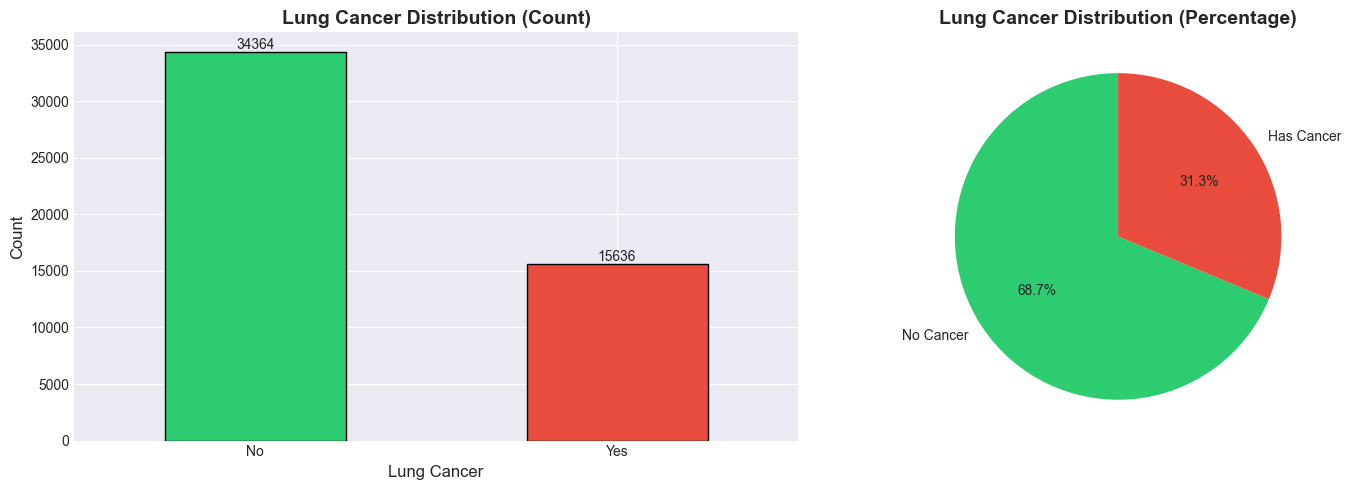

✓ Target distribution visualization completed!


In [5]:
# Data Visualization - Part 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count Plot
ax1 = axes[0]
df['lung_cancer'].value_counts().plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_title('Lung Cancer Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Lung Cancer', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(['No', 'Yes'], rotation=0)
for container in ax1.containers:
    ax1.bar_label(container)

# Pie Chart
ax2 = axes[1]
df['lung_cancer'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', 
                                       colors=['#2ecc71', '#e74c3c'], startangle=90,
                                       labels=['No Cancer', 'Has Cancer'])
ax2.set_title('Lung Cancer Distribution (Percentage)', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Target distribution visualization completed!')

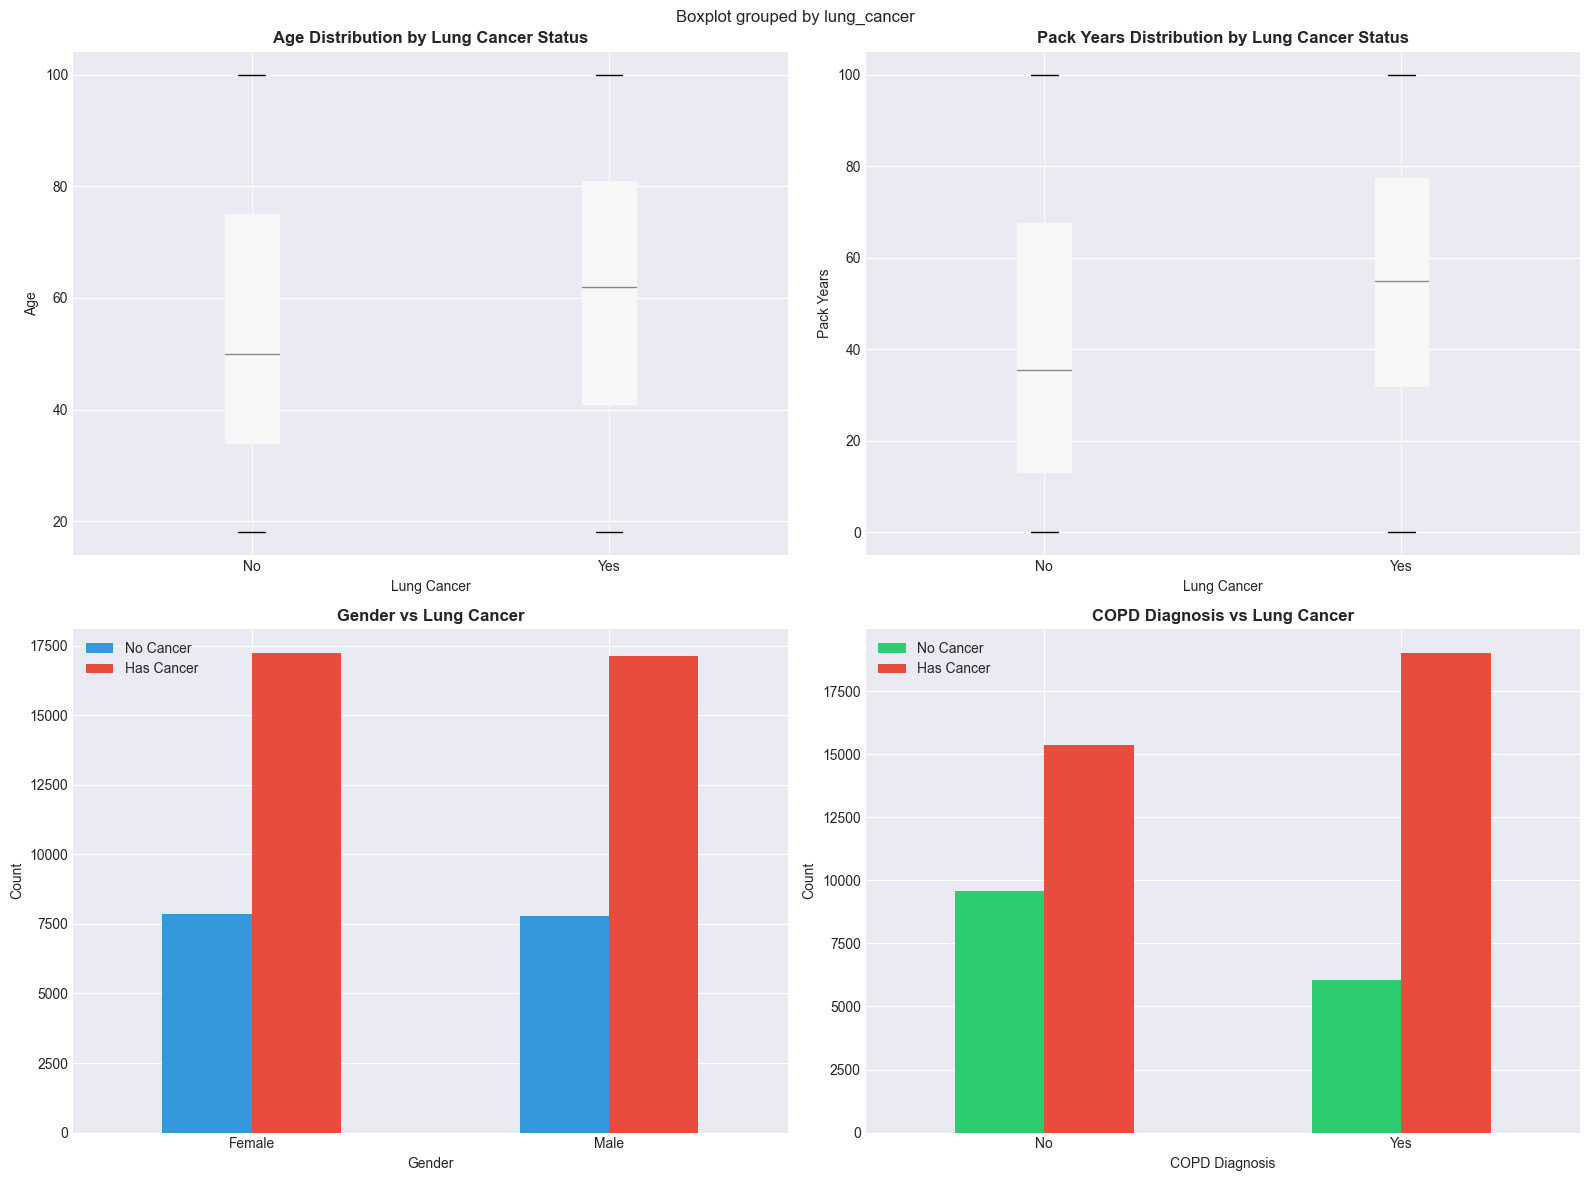

✓ Feature analysis visualization completed!


In [6]:
# Data Visualization - Part 2: Feature Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age Distribution
ax1 = axes[0, 0]
df.boxplot(column='age', by='lung_cancer', ax=ax1, patch_artist=True)
ax1.set_title('Age Distribution by Lung Cancer Status', fontsize=12, fontweight='bold')
ax1.set_xlabel('Lung Cancer', fontsize=10)
ax1.set_ylabel('Age', fontsize=10)
plt.sca(ax1)
plt.xticks([1, 2], ['No', 'Yes'])

# Pack Years Distribution
ax2 = axes[0, 1]
df.boxplot(column='pack_years', by='lung_cancer', ax=ax2, patch_artist=True)
ax2.set_title('Pack Years Distribution by Lung Cancer Status', fontsize=12, fontweight='bold')
ax2.set_xlabel('Lung Cancer', fontsize=10)
ax2.set_ylabel('Pack Years', fontsize=10)
plt.sca(ax2)
plt.xticks([1, 2], ['No', 'Yes'])

# Gender Distribution
ax3 = axes[1, 0]
pd.crosstab(df['gender'], df['lung_cancer']).plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c'])
ax3.set_title('Gender vs Lung Cancer', fontsize=12, fontweight='bold')
ax3.set_xlabel('Gender', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.legend(['No Cancer', 'Has Cancer'])
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# COPD Diagnosis
ax4 = axes[1, 1]
pd.crosstab(df['copd_diagnosis'], df['lung_cancer']).plot(kind='bar', ax=ax4, color=['#2ecc71', '#e74c3c'])
ax4.set_title('COPD Diagnosis vs Lung Cancer', fontsize=12, fontweight='bold')
ax4.set_xlabel('COPD Diagnosis', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.legend(['No Cancer', 'Has Cancer'])
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Feature analysis visualization completed!')

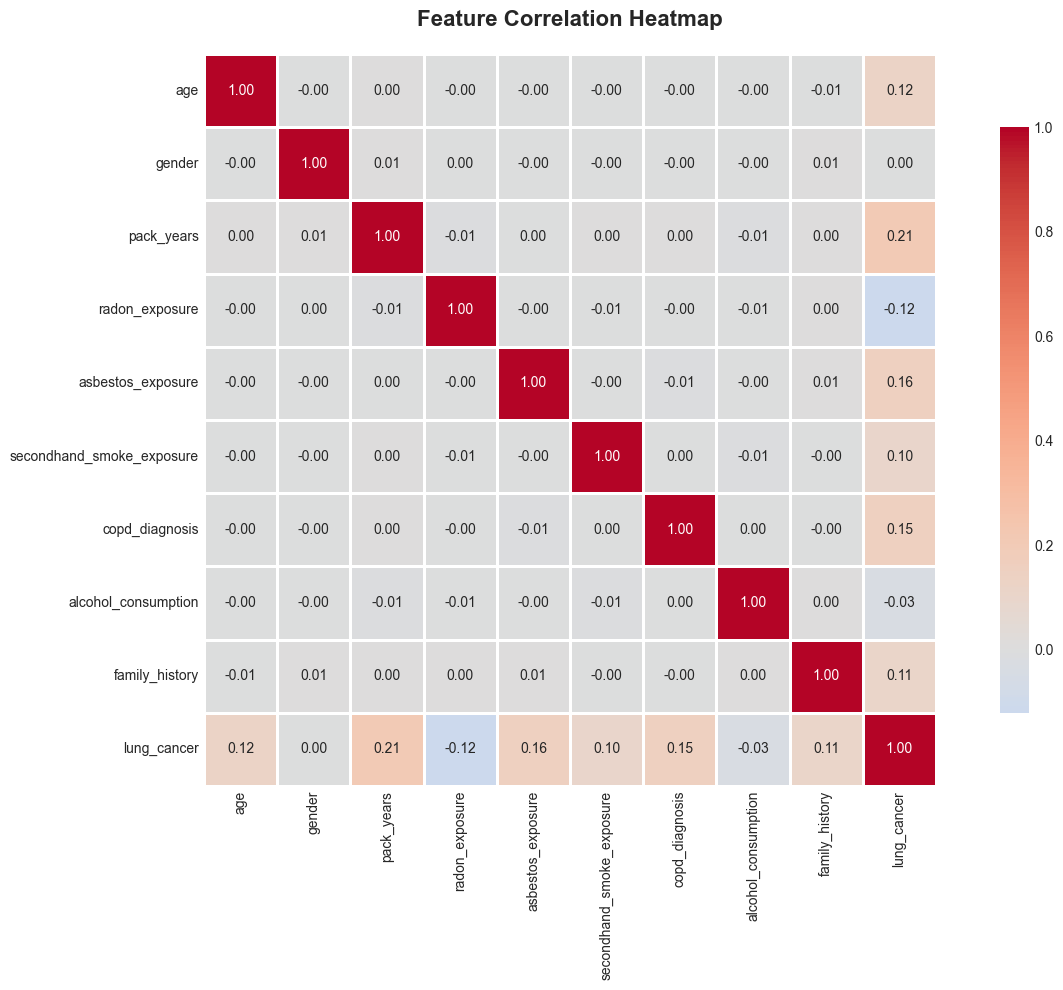

✓ Correlation heatmap completed!


In [7]:
# Correlation Heatmap
# First, encode categorical variables for correlation
df_encoded = df.copy()
le = LabelEncoder()

categorical_cols = ['gender', 'radon_exposure', 'asbestos_exposure', 
                   'secondhand_smoke_exposure', 'copd_diagnosis', 
                   'alcohol_consumption', 'family_history', 'lung_cancer']

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Drop patient_id for correlation
df_corr = df_encoded.drop('patient_id', axis=1)

plt.figure(figsize=(14, 10))
correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Correlation heatmap completed!')

In [8]:
# Data Preprocessing
print('Starting Data Preprocessing...')
print('='*60)

# Create a copy of the dataset
df_processed = df.copy()

# Drop patient_id as it's not a feature
df_processed = df_processed.drop('patient_id', axis=1)

# Separate features and target
X = df_processed.drop('lung_cancer', axis=1)
y = df_processed['lung_cancer']

# Encode target variable
label_encoder_y = LabelEncoder()
y_encoded = label_encoder_y.fit_transform(y)

print(f'Original Target Classes: {label_encoder_y.classes_}')
print(f'Encoded Target: 0 = {label_encoder_y.classes_[0]}, 1 = {label_encoder_y.classes_[1]}')

# Encode categorical features
categorical_features = ['gender', 'radon_exposure', 'asbestos_exposure', 
                       'secondhand_smoke_exposure', 'copd_diagnosis', 
                       'alcohol_consumption', 'family_history']

label_encoders = {}
X_encoded = X.copy()

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f'\n{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\n' + '='*60)
print('✓ Preprocessing completed!')
print(f'\nFinal Feature Shape: {X_encoded.shape}')
print(f'Final Target Shape: {y_encoded.shape}')

Starting Data Preprocessing...
Original Target Classes: ['No' 'Yes']
Encoded Target: 0 = No, 1 = Yes

gender: {'Female': 0, 'Male': 1}

radon_exposure: {'High': 0, 'Low': 1, 'Medium': 2}

asbestos_exposure: {'No': 0, 'Yes': 1}

secondhand_smoke_exposure: {'No': 0, 'Yes': 1}

copd_diagnosis: {'No': 0, 'Yes': 1}

alcohol_consumption: {'Heavy': 0, 'Moderate': 1, 'None': 2}

family_history: {'No': 0, 'Yes': 1}

✓ Preprocessing completed!

Final Feature Shape: (50000, 9)
Final Target Shape: (50000,)


In [9]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Dataset Split Completed!')
print('='*60)
print(f'Training Set Size: {X_train.shape[0]} samples')
print(f'Testing Set Size: {X_test.shape[0]} samples')
print(f'\nTraining Set - Positive Cases: {sum(y_train)} ({sum(y_train)/len(y_train)*100:.2f}%)')
print(f'Testing Set - Positive Cases: {sum(y_test)} ({sum(y_test)/len(y_test)*100:.2f}%)')

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\n✓ Feature scaling completed!')

Dataset Split Completed!
Training Set Size: 40000 samples
Testing Set Size: 10000 samples

Training Set - Positive Cases: 27491 (68.73%)
Testing Set - Positive Cases: 6873 (68.73%)

✓ Feature scaling completed!


In [10]:
# Initialize All Models
print('Initializing Machine Learning Models...')
print('='*60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print(f'Total Models to Train: {len(models)}')
for i, model_name in enumerate(models.keys(), 1):
    print(f'{i}. {model_name}')
print('\n✓ Models initialized successfully!')

Initializing Machine Learning Models...
Total Models to Train: 7
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Naive Bayes
6. XGBoost
7. Gradient Boosting

✓ Models initialized successfully!


In [11]:
# Train All Models and Store Results
print('Training All Models...')
print('='*60)

results = []
trained_models = {}

for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    # ROC AUC Score
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = accuracy  # Fallback for models without probability
    
    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV Score': cv_mean
    })
    
    # Store trained model
    trained_models[model_name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f'✓ {model_name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}')

print('\n' + '='*60)
print('✓ All models trained successfully!')

Training All Models...

Training Logistic Regression...
✓ Logistic Regression - Accuracy: 0.7237, F1-Score: 0.8182

Training Decision Tree...
✓ Decision Tree - Accuracy: 0.6513, F1-Score: 0.7448

Training Random Forest...
✓ Random Forest - Accuracy: 0.7025, F1-Score: 0.7916

Training K-Nearest Neighbors...
✓ K-Nearest Neighbors - Accuracy: 0.6945, F1-Score: 0.7886

Training Naive Bayes...
✓ Naive Bayes - Accuracy: 0.7294, F1-Score: 0.8246

Training XGBoost...
✓ XGBoost - Accuracy: 0.7341, F1-Score: 0.8197

Training Gradient Boosting...
✓ Gradient Boosting - Accuracy: 0.7440, F1-Score: 0.8294

✓ All models trained successfully!


In [12]:
# Create Results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('\nMODEL PERFORMANCE COMPARISON')
print('='*100)
print(results_df.to_string(index=False))
print('='*100)

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']

print(f'\n🏆 BEST MODEL: {best_model_name} with Accuracy: {best_accuracy:.4f}')

# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print('\n✓ Results saved to model_comparison_results.csv')


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV Score
  Gradient Boosting    0.7440   0.765024 0.905718  0.829447 0.776438  0.737400
            XGBoost    0.7341   0.767522 0.879529  0.819717 0.760058  0.723725
        Naive Bayes    0.7294   0.743599 0.925360  0.824582 0.752908  0.723050
Logistic Regression    0.7237   0.746758 0.904845  0.818236 0.741134  0.717900
      Random Forest    0.7025   0.763378 0.821912  0.791564 0.722239  0.700975
K-Nearest Neighbors    0.6945   0.751847 0.829187  0.788625 0.684135  0.690475
      Decision Tree    0.6513   0.749337 0.740288  0.744785 0.597998  0.651725

🏆 BEST MODEL: Gradient Boosting with Accuracy: 0.7440

✓ Results saved to model_comparison_results.csv


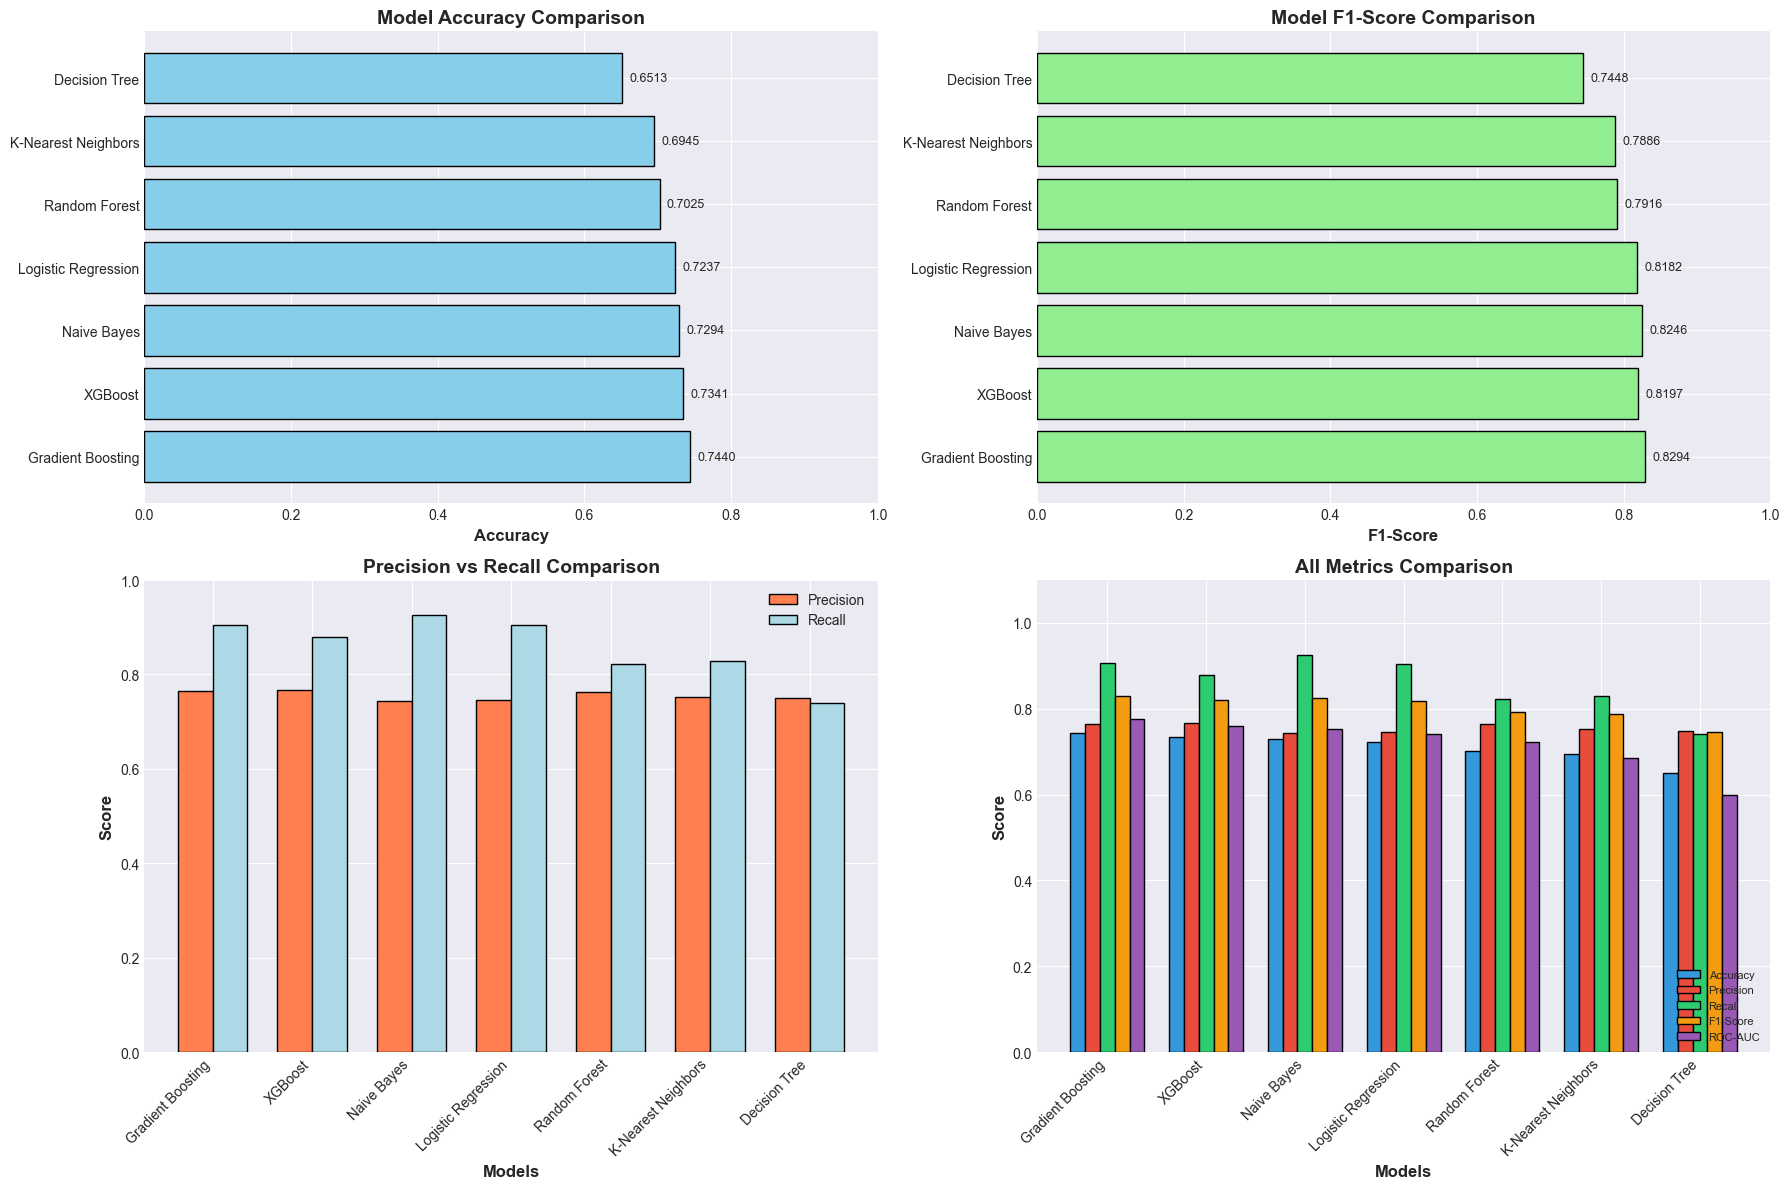

✓ Model comparison visualization completed!


In [13]:
# Visualization - Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy Comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(results_df['Model'], results_df['Accuracy'], color='skyblue', edgecolor='black')
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# F1-Score Comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(results_df['Model'], results_df['F1-Score'], color='lightgreen', edgecolor='black')
ax2.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 1])
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

# Precision vs Recall
ax3 = axes[1, 0]
x = np.arange(len(results_df))
width = 0.35
bars3 = ax3.bar(x - width/2, results_df['Precision'], width, label='Precision', color='coral', edgecolor='black')
bars4 = ax3.bar(x + width/2, results_df['Recall'], width, label='Recall', color='lightblue', edgecolor='black')
ax3.set_xlabel('Models', fontsize=12, fontweight='bold')
ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('Precision vs Recall Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax3.legend()
ax3.set_ylim([0, 1])

# Overall Metrics Comparison
ax4 = axes[1, 1]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    offset = width * (i - 2)
    ax4.bar(x + offset, results_df[metric], width, label=metric, color=colors[i], edgecolor='black')

ax4.set_xlabel('Models', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax4.legend(loc='lower right', fontsize=8)
ax4.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('model_comparison_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Model comparison visualization completed!')

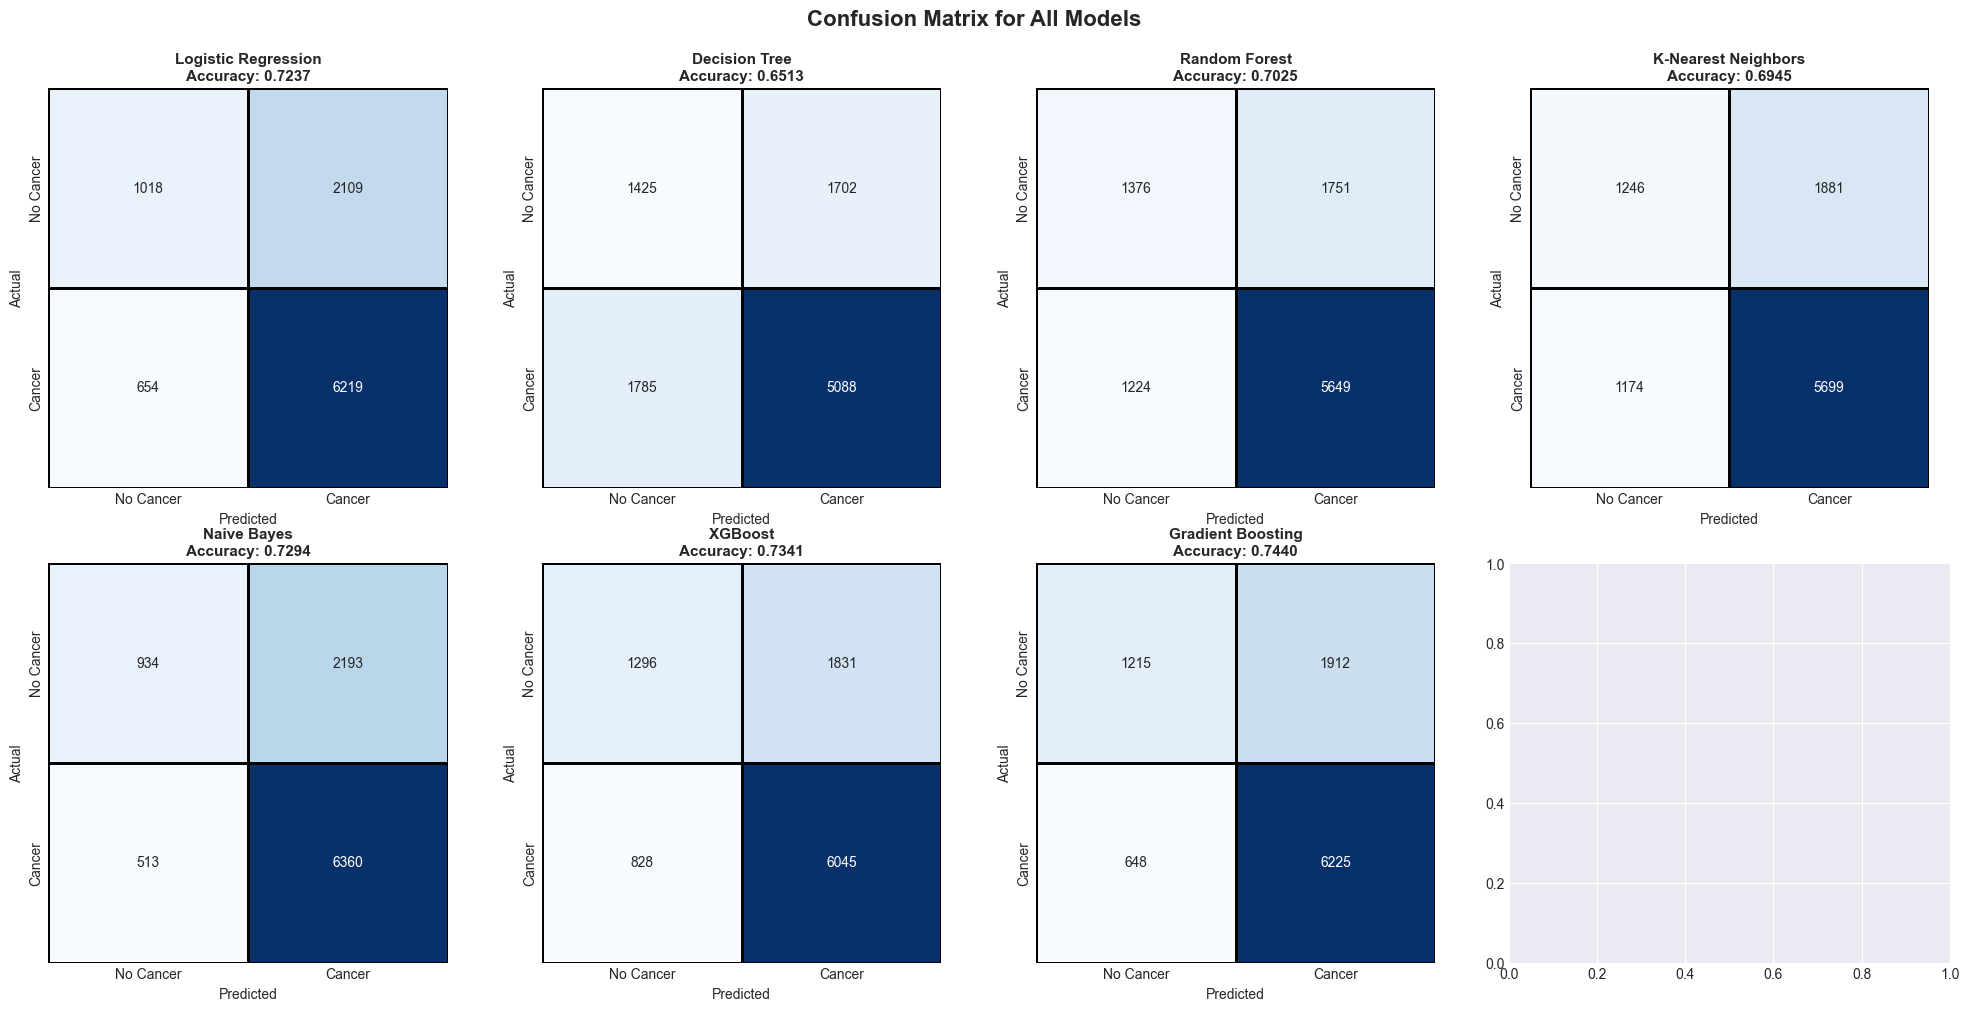

✓ Confusion matrices visualization completed!


In [14]:
# Confusion Matrix for All Models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, (model_name, model_data) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model_data['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=False, square=True, linewidths=1, linecolor='black')
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test, model_data["predictions"]):.4f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xticklabels(['No Cancer', 'Cancer'])
    axes[idx].set_yticklabels(['No Cancer', 'Cancer'])

plt.suptitle('Confusion Matrix for All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Confusion matrices visualization completed!')

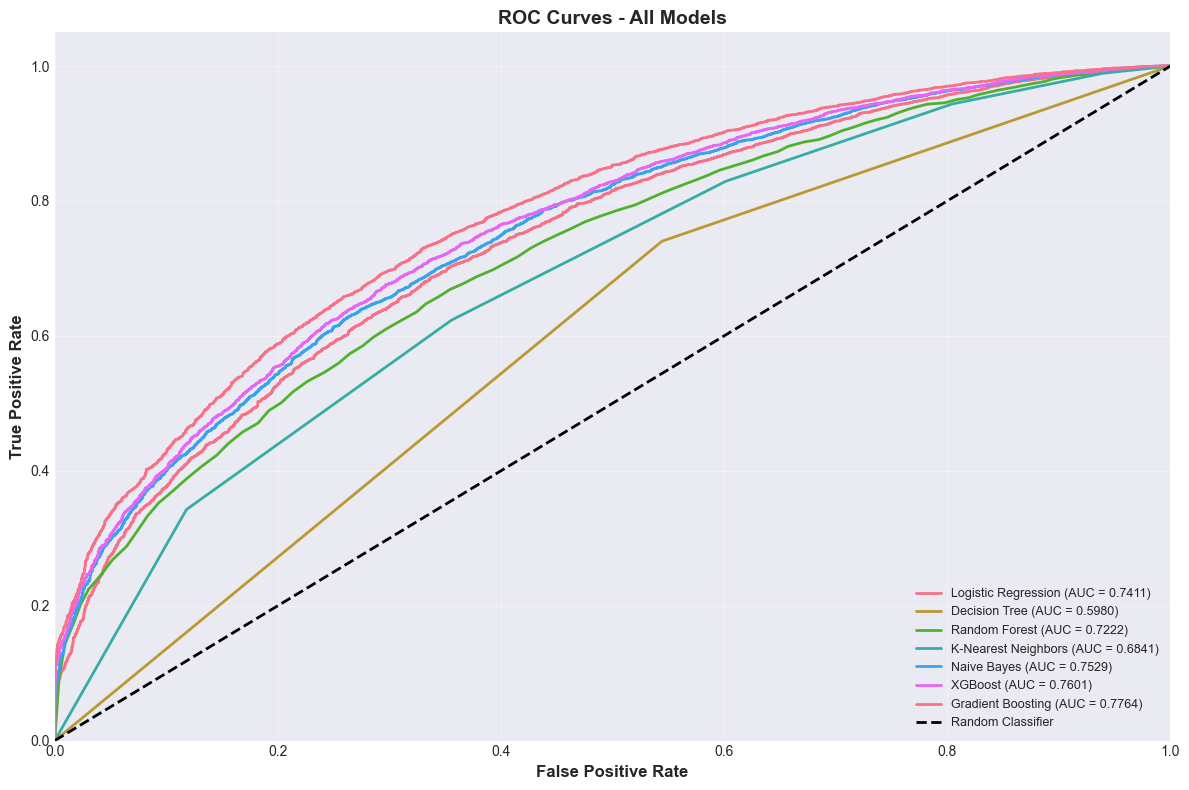

✓ ROC curves visualization completed!


In [15]:
# ROC Curves for All Models
plt.figure(figsize=(12, 8))

for model_name, model_data in trained_models.items():
    if model_data['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, model_data['probabilities'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ ROC curves visualization completed!')

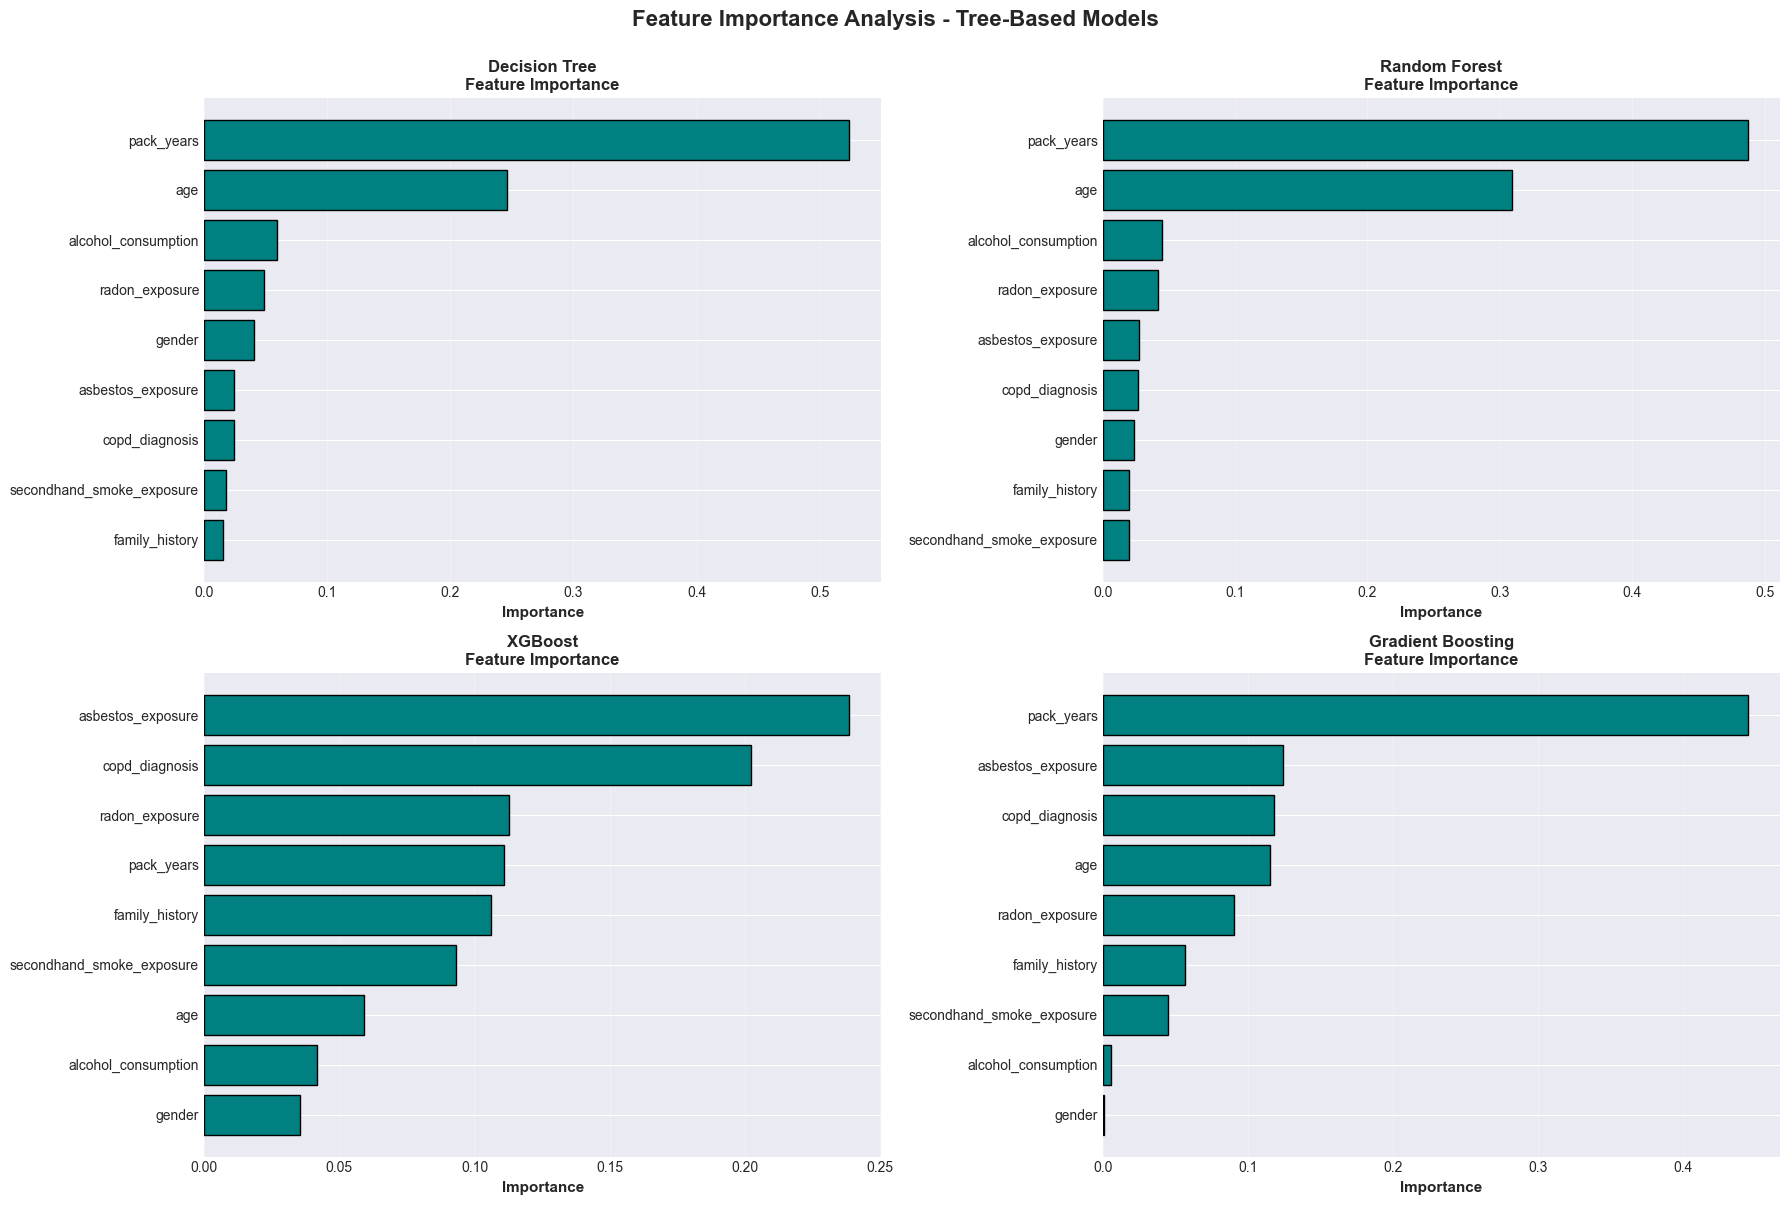

✓ Feature importance visualization completed!


In [16]:
# Feature Importance Analysis (for tree-based models)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

tree_models = ['Decision Tree', 'Random Forest', 'XGBoost', 'Gradient Boosting']
feature_names = X_encoded.columns

for idx, model_name in enumerate(tree_models):
    if model_name in trained_models:
        model = trained_models[model_name]['model']
        importance = model.feature_importances_
        
        # Create DataFrame and sort
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=True)
        
        # Plot
        axes[idx].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
                      color='teal', edgecolor='black')
        axes[idx].set_xlabel('Importance', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{model_name}\nFeature Importance', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Analysis - Tree-Based Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Feature importance visualization completed!')

In [17]:
# Detailed Classification Report for Best Model
best_model = trained_models[best_model_name]['model']
best_predictions = trained_models[best_model_name]['predictions']

print(f'\n{"="*80}')
print(f'DETAILED CLASSIFICATION REPORT - {best_model_name.upper()}')
print(f'{"="*80}\n')
print(classification_report(y_test, best_predictions, 
                          target_names=['No Cancer', 'Has Cancer'],
                          digits=4))

# Confusion Matrix for Best Model
cm = confusion_matrix(y_test, best_predictions)
print(f'\n{"="*80}')
print('CONFUSION MATRIX BREAKDOWN')
print(f'{"="*80}')
print(f'True Negatives (Correctly predicted No Cancer): {cm[0][0]}')
print(f'False Positives (Incorrectly predicted Cancer): {cm[0][1]}')
print(f'False Negatives (Incorrectly predicted No Cancer): {cm[1][0]}')
print(f'True Positives (Correctly predicted Cancer): {cm[1][1]}')
print(f'{"="*80}')


DETAILED CLASSIFICATION REPORT - GRADIENT BOOSTING

              precision    recall  f1-score   support

   No Cancer     0.6522    0.3886    0.4870      3127
  Has Cancer     0.7650    0.9057    0.8294      6873

    accuracy                         0.7440     10000
   macro avg     0.7086    0.6471    0.6582     10000
weighted avg     0.7297    0.7440    0.7224     10000


CONFUSION MATRIX BREAKDOWN
True Negatives (Correctly predicted No Cancer): 1215
False Positives (Incorrectly predicted Cancer): 1912
False Negatives (Incorrectly predicted No Cancer): 648
True Positives (Correctly predicted Cancer): 6225


In [18]:
# Save the Best Model
print('\nSaving Models and Preprocessors...')
print('='*60)

# Save best model using joblib
joblib.dump(best_model, 'lung_cancer_best_model.pkl')
print(f'✓ Best Model ({best_model_name}) saved as: lung_cancer_best_model.pkl')

# Save best model using pickle
with open('lung_cancer_best_model_pickle.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'✓ Best Model ({best_model_name}) saved as: lung_cancer_best_model_pickle.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print('✓ Scaler saved as: scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print('✓ Label Encoders saved as: label_encoders.pkl')

# Save target encoder
joblib.dump(label_encoder_y, 'target_encoder.pkl')
print('✓ Target Encoder saved as: target_encoder.pkl')

# Save all models
all_models_dict = {name: data['model'] for name, data in trained_models.items()}
joblib.dump(all_models_dict, 'all_trained_models.pkl')
print('✓ All Models saved as: all_trained_models.pkl')

print('\n' + '='*60)
print('✓ All models and preprocessors saved successfully!')


Saving Models and Preprocessors...
✓ Best Model (Gradient Boosting) saved as: lung_cancer_best_model.pkl
✓ Best Model (Gradient Boosting) saved as: lung_cancer_best_model_pickle.pkl
✓ Scaler saved as: scaler.pkl
✓ Label Encoders saved as: label_encoders.pkl
✓ Target Encoder saved as: target_encoder.pkl
✓ All Models saved as: all_trained_models.pkl

✓ All models and preprocessors saved successfully!


In [19]:
# Model Prediction Example
print('\nMODEL PREDICTION EXAMPLE')
print('='*80)

# Take a sample from test set
sample_index = 0
sample_features = X_test.iloc[sample_index:sample_index+1]
actual_label = y_test[sample_index]

print('\nSample Patient Features:')
print('-'*80)
for col in sample_features.columns:
    print(f'{col}: {sample_features[col].values[0]}')

print('\n' + '-'*80)
print(f'Actual Diagnosis: {label_encoder_y.classes_[actual_label]}')
print('-'*80)

# Make prediction with best model
sample_scaled = scaler.transform(sample_features)
prediction = best_model.predict(sample_scaled)[0]
prediction_proba = best_model.predict_proba(sample_scaled)[0] if hasattr(best_model, 'predict_proba') else None

print(f'\nPredicted Diagnosis: {label_encoder_y.classes_[prediction]}')
if prediction_proba is not None:
    print(f'Confidence: No Cancer = {prediction_proba[0]*100:.2f}%, Has Cancer = {prediction_proba[1]*100:.2f}%')

print('\n' + '='*80)
if prediction == actual_label:
    print('✓ PREDICTION CORRECT!')
else:
    print('✗ PREDICTION INCORRECT')
print('='*80)


MODEL PREDICTION EXAMPLE

Sample Patient Features:
--------------------------------------------------------------------------------
age: 28
gender: 0
pack_years: 1.120185073262281
radon_exposure: 1
asbestos_exposure: 0
secondhand_smoke_exposure: 0
copd_diagnosis: 1
alcohol_consumption: 2
family_history: 0

--------------------------------------------------------------------------------
Actual Diagnosis: No
--------------------------------------------------------------------------------

Predicted Diagnosis: No
Confidence: No Cancer = 79.25%, Has Cancer = 20.75%

✓ PREDICTION CORRECT!


In [20]:
# Final Summary
print('\n' + '='*80)
print('PROJECT SUMMARY - LUNG CANCER PREDICTION')
print('='*80)
print(f'\nTotal Records Processed: {len(df)}')
print(f'Training Samples: {len(X_train)}')
print(f'Testing Samples: {len(X_test)}')
print(f'Number of Features: {X_encoded.shape[1]}')
print(f'\nTotal Models Trained: {len(models)}')
print(f'Best Performing Model: {best_model_name}')
print(f'Best Model Accuracy: {best_accuracy:.4f}')
print(f'Best Model F1-Score: {results_df.iloc[0]["F1-Score"]:.4f}')
print(f'Best Model ROC-AUC: {results_df.iloc[0]["ROC-AUC"]:.4f}')

print('\n' + '-'*80)
print('FILES GENERATED:')
print('-'*80)
print('1. lung_cancer_best_model.pkl - Best trained model')
print('2. scaler.pkl - Feature scaler')
print('3. label_encoders.pkl - Categorical encoders')
print('4. target_encoder.pkl - Target variable encoder')
print('5. all_trained_models.pkl - All trained models')
print('6. model_comparison_results.csv - Performance metrics')
print('7. target_distribution.png - Target analysis')
print('8. feature_analysis.png - Feature exploration')
print('9. correlation_heatmap.png - Feature correlations')
print('10. model_comparison_visualization.png - Model comparisons')
print('11. confusion_matrices.png - All confusion matrices')
print('12. roc_curves.png - ROC curves for all models')
print('13. feature_importance.png - Feature importance analysis')

print('\n' + '='*80)
print('✓ LUNG CANCER PREDICTION PROJECT COMPLETED SUCCESSFULLY!')
print('='*80)


PROJECT SUMMARY - LUNG CANCER PREDICTION

Total Records Processed: 50000
Training Samples: 40000
Testing Samples: 10000
Number of Features: 9

Total Models Trained: 7
Best Performing Model: Gradient Boosting
Best Model Accuracy: 0.7440
Best Model F1-Score: 0.8294
Best Model ROC-AUC: 0.7764

--------------------------------------------------------------------------------
FILES GENERATED:
--------------------------------------------------------------------------------
1. lung_cancer_best_model.pkl - Best trained model
2. scaler.pkl - Feature scaler
3. label_encoders.pkl - Categorical encoders
4. target_encoder.pkl - Target variable encoder
5. all_trained_models.pkl - All trained models
6. model_comparison_results.csv - Performance metrics
7. target_distribution.png - Target analysis
8. feature_analysis.png - Feature exploration
9. correlation_heatmap.png - Feature correlations
10. model_comparison_visualization.png - Model comparisons
11. confusion_matrices.png - All confusion matrices


## How to Use the Saved Model\n\n
```python\n
# Load the model and preprocessors\n
import joblib\n
import pandas as pd\n\n
# Load saved files\n
model = joblib.load('lung_cancer_best_model.pkl')\n
scaler = joblib.load('scaler.pkl')\n
label_encoders = joblib.load('label_encoders.pkl')\n
target_encoder = joblib.load('target_encoder.pkl')\n\n
# Prepare new patient data\n
new_patient = {\n
    'age': 65,\n
    'gender': 'Male',\n
    'pack_years': 50.5,\n
    'radon_exposure': 'High',\n
    'asbestos_exposure': 'Yes',\n
    'secondhand_smoke_exposure': 'Yes',\n
    'copd_diagnosis': 'Yes',\n
    'alcohol_consumption': 'Moderate',\n
    'family_history': 'Yes'\n
}\n\n
# Convert to DataFrame\n
patient_df = pd.DataFrame([new_patient])\n\n
# Encode categorical features\n
for col, encoder in label_encoders.items():\n
    patient_df[col] = encoder.transform(patient_df[col])\n\n
# Scale features\n
patient_scaled = scaler.transform(patient_df)\n\n
# Make prediction\n
prediction = model.predict(patient_scaled)[0]\n
probability = model.predict_proba(patient_scaled)[0]\n\n
# Decode prediction\n
result = target_encoder.inverse_transform([prediction])[0]\n
print(f'Prediction: {result}')\n
print(f'Probability: No Cancer = {probability[0]*100:.2f}%, Has Cancer = {probability[1]*100:.2f}%')\n
```